# Introduction to Linear Algebra

In [1]:
import numpy as np
import sympy as sp

## Dot Products

The dot product or inner product, of vector $\mathbf{v}=(v_1, v_2, \dots, v_n)$ and vector $\mathbf{w}=(w_1, w_2, \dots, w_n)$ is

$$
\mathbf{v} \cdot \mathbf{w} = \mathbf{w} \cdot \mathbf{v} = \sum_{i=1}^{n} v_i w_i.
$$

### Lengths

An important case is the dot product of a vector with itself. The dot product $\mathbf{v} \cdot \mathbf{v}$ gives the length of $\mathbf{v}$ squared.

$$
\|\mathbf{v}\| = \sqrt{\mathbf{v} \cdot \mathbf{v}} = \sqrt{\sum_{i=1}^{n}v_i^2}.
$$

A vector with length 1 is called a unit vector, denoted with a hat,

$$
\mathbf{\hat{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|}.
$$

### Angles

*Theorem.* When $\mathbf{v}$ is perpendicular to $\mathbf{w}$, $\mathbf{v} \cdot \mathbf{w} = 0$.

*Proof.* By the Pythagorean Law,

$$
\begin{aligned}
                        \|\mathbf{v}\|^2 + \|\mathbf{w}\|^2 &= \|\mathbf{v}-\mathbf{w}\|^2 \\
\sum_{i=1}^{n} v_i^2 \sum_{i=1}^{n} w_i^2 &= \sum_{i=1}^{n} (v_i - w_i)^2 \\
                                          &= \sum_{i=1}^{n} v_i^2 + w_i^2 - 2v_iw_i \\
                                        0 &= -2\sum_{i=1}^{n} v_iw_i \\
              \mathbf{v} \cdot \mathbf{w} &= 0.
\end{aligned}
$$

End of proof.

Now, suppose $\mathbf{v}$ and $\mathbf{w}$ aren't perpendicular; the Pythagorean Law no longer applies. Instead, we use the Law of Cosines:

$$
\begin{aligned}
 \|\mathbf{v}-\mathbf{w}\|^2 &= \|\mathbf{v}\|^2 + \|\mathbf{w}\|^2 - 2\|\mathbf{v}\| \|\mathbf{w}\| \cos \theta \\
\cos \theta &= \frac{\mathbf{v} \cdot \mathbf{w}}{\|\mathbf{v}\| \|\mathbf{w}\|}
\end{aligned}
$$

The math works similarly with the above. Now we arrive at an equation that allows us to measure the angle between two vectors. 

In [2]:
v = np.array([2, 3, 4])
w = np.array([1, 1, 1])

In [3]:
np.acos(v @ w / np.linalg.norm(v) / np.linalg.norm(w))  # Angle between v and w, in radians

np.float64(0.2657291189694247)

## Gaussian Elimination

To convert a matrix $\mathbf{A}$ into an upper triangular matrix via **Gaussian elimination**, you perform **elementary row operations** to zero out the entries below the main diagonal.

Given

$$
\mathbf{A} = \begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33}
\end{bmatrix}.
$$

Goal is to transform $\mathbf{A}$ to an upper triangular matrix $\mathbf{U}$ of the form

$$
\mathbf{U} = \begin{bmatrix}
u_{11} & u_{12} & u_{13} \\
0 & u_{22} & u_{23} \\
0 & 0 & u_{33}
\end{bmatrix}.
$$

### Procedure

1. Eliminate below $a_{11}$: \
   For row 2,

   $$
   R_2 \leftarrow R_2 - \frac{a_{21}}{a_{11}} R_1.
   $$

   For row 3,

   $$
   R_3 \leftarrow R_3 - \frac{a_{31}}{a_{11}} R_1.
   $$

2. Eliminate below $a_{22}$:
   Let the new value at $(2,2)$ be $a'_{22}$, and the value at $(3,2)$ be $a'_{32}$. Then,

   $$
   R_3 \leftarrow R_3 - \frac{a'_{32}}{a'_{22}} R_2.
   $$


### Example

$$
\mathbf{A} = \begin{bmatrix}
2 & 4 & -2 \\
4 & 9 & -3 \\
-2 & -3 & 7
\end{bmatrix}
\quad
\overset{R_2 \leftarrow R_2 - 2R_1}{\longrightarrow}
\quad
\begin{bmatrix}
2 & 4 & -2 \\
0 & 1 & 1 \\
-2 & -3 & 7
\end{bmatrix}
\quad
\overset{R_3 \leftarrow R_3 - (-R_1)}{\longrightarrow}
\quad
\begin{bmatrix}
2 & 4 & -2 \\
0 & 1 & 1 \\
0 & 1 & 5
\end{bmatrix}
\quad
\overset{R_3 \leftarrow R_3 - R_2}{\longrightarrow}
\quad
\mathbf{U} = \begin{bmatrix}
2 & 4 & -2 \\
0 & 1 & 1 \\
0 & 0 & 4
\end{bmatrix}.
$$

To solve $\mathbf{Ax}=\mathbf{b}$, we may augment the vector $\mathbf{b}$ to $\mathbf{A}$ when performing elimination. After getting $\mathbf{Ux}=\mathbf{c}$, do back substitution.

In [4]:
A = np.array([[2, 4, -2],
              [4, 9, -3],
              [-2, -3, 7]], dtype=np.float64)
b = np.array([[2],
              [8],
              [10]], dtype=np.float64)

In [5]:
tmp = np.hstack([A.copy(), b.copy()])

e21 = tmp[1, 0] / tmp[0, 0]
tmp[1, :] -= e21 * tmp[0, :]

e31 = tmp[2, 0] / tmp[0, 0]
tmp[2, :] -= e31 * tmp[0, :]

e32 = tmp[2, 1] / tmp[1, 1]
tmp[2, :] -= e32 * tmp[1, :]

U, c = tmp[:, :-1], tmp[:, [-1]]
U, c

(array([[ 2.,  4., -2.],
        [ 0.,  1.,  1.],
        [ 0.,  0.,  4.]]),
 array([[2.],
        [4.],
        [8.]]))

## LU Factorization

Each step from $\mathbf{A}$ to $\mathbf{U}$ multiplies by a matrix $\mathbf{E_{ij}}$ to produce zero in the $(i, j)$ position,

$$
\underbrace{(\mathbf{E}_{32}\mathbf{E}_{31}\mathbf{E}_{21})}_{\mathbf{E}}\mathbf{A} = \mathbf{U}.
$$

Matrix $\mathbf{E}_{ij}$ is an identity matrix with the multiplier in the $(i, j)$ position.

Letting $\mathbf{L}=\mathbf{E}^{-1}$, we obtain the LU factorization,

$$
\mathbf{A} = \mathbf{LU}.
$$

The upper triangular $\mathbf{U}$ has the pivots on its diagonal. The lower triangular $\mathbf{L}$ has all l's on its diagonal. The multipliers are below the diagonal of $\mathbf{L}$.

### $\mathbf{PA} = \mathbf{LU}$

The factorization doesn't always work. Sometimes row exchanges are needed to produce pivots. To handle such situations, we introduce a permutation matrix $\mathbf{P}$, which records the row swaps required during Gaussian elimination. This leads to the more general form of LU factorization,

$$
\mathbf{PA} = \mathbf{LU}.
$$

In [6]:
e21, e31, e32

(np.float64(2.0), np.float64(-1.0), np.float64(1.0))

In [7]:
L = np.identity(A.shape[0])
L[1, 0] = e21
L[2, 0] = e31
L[2, 1] = e32
L

array([[ 1.,  0.,  0.],
       [ 2.,  1.,  0.],
       [-1.,  1.,  1.]])

In [8]:
L @ U

array([[ 2.,  4., -2.],
       [ 4.,  9., -3.],
       [-2., -3.,  7.]])

In [9]:
np.allclose(L @ U, A)

True

In [10]:
L1, U1, perm = sp.Matrix(A).LUdecomposition()
L1, U1, perm

(Matrix([
 [   1,   0, 0],
 [ 2.0,   1, 0],
 [-1.0, 1.0, 1]]),
 Matrix([
 [2.0, 4.0, -2.0],
 [  0, 1.0,  1.0],
 [  0,   0,  4.0]]),
 [])

In [11]:
np.allclose(L1 @ U1, A)

True

### $\mathbf{PA} = \mathbf{LDU}$

$\mathbf{PA} = \mathbf{LU}$ is "unsymmetric" because $\mathbf{U}$ has the pivots on its diagonal where $\mathbf{L}$ has 1's. This is easy to change. Divide $\mathbf{U}$ by a diagonal matrix $\mathbf{D}$ that contains the pivots. That leaves a new triangular matrix with 1's on the diagonal:

$$
\begin{bmatrix}
d_1 &        &        &        \\
    & d_2    &        &        \\
    &        & \ddots &        \\
    &        &        & d_n
\end{bmatrix}
\begin{bmatrix}
1           & \frac{u_{12}}{d_1} & \frac{u_{13}}{d_1} & \cdots \\
            & 1                 & \frac{u_{23}}{d_2} & \cdots \\
            &                   & \ddots            & \vdots \\
            &                   &                   & 1
\end{bmatrix}.
$$

In [12]:
pivots = np.diag(U)
D = np.diag(pivots)
D

array([[2., 0., 0.],
       [0., 1., 0.],
       [0., 0., 4.]])

In [13]:
Ud = U / pivots.reshape(-1, 1)
Ud

array([[ 1.,  2., -1.],
       [ 0.,  1.,  1.],
       [ 0.,  0.,  1.]])

In [14]:
np.allclose(L @ D @ Ud, A)

True

## Vector Spaces

*Definition.* The space $\mathbb{R}^n$ consists of all column vectors $\mathbf{v}$ with $n$ components.

### Column Spaces

*Definition.* The **column space $\text{Col}(\mathbf{A})$** consists of all linear combinations of the columns of $\mathbf{A}$. The combinations are all possible vectors $\mathbf{Ax}$.

In other words, the system $\mathbf{Ax} = \mathbf{b}$ is solvable if and only if $\mathbf{b}$ is in $\text{Col}(\mathbf{A})$.

*Definition.* The vectors are a **basis** for a space if they are independent and they span the space.

*Definition.* The **dimension** of a vector space is the number of vectors in a basis for the space.

### Nullspaces

*Definition.* The **nullspace** (also called the kernel) $\text{Null}(\mathbf{A})$ is the set of all vectors $\mathbf{x}$ such that $\mathbf{Ax}=\mathbf{0}$.

A zero vector $\mathbf{0}$ will always be the solution to the equation. To find other **special solutions**, we perform elimination on $\mathbf{A}$ to produce a reduced row echelon form (RREF) of the matrix, which we'll denote as $\mathbf{R}$. RREF is a stricter form of $\mathbf{U}$, with pivots being 1 and zeros above and below pivots. Here is an example:

$$
\mathbf{A} = \begin{bmatrix}
1 & 1 & 2 & 4 \\
1 & 2 & 2 & 5 \\
1 & 3 & 2 & 6 \\
\end{bmatrix}
\quad
\overset{\begin{aligned}R_2 \leftarrow R_2 - R_1\\ R_3 \leftarrow R_3 - R_1\end{aligned}}{\longrightarrow}
\quad
\begin{bmatrix}
1 & 1 & 2 & 4 \\
0 & 1 & 0 & 1 \\
0 & 2 & 0 & 2 \\
\end{bmatrix}
\quad
\overset{R_3 \leftarrow R_3 - 2R_2}{\longrightarrow}
\quad
\mathbf{U} = \begin{bmatrix}
1 & 1 & 2 & 4 \\
0 & 1 & 0 & 1 \\
0 & 0 & 0 & 0 \\
\end{bmatrix}
\quad
\overset{R_1 \leftarrow R_1 - R_2}{\longrightarrow}
\quad
\mathbf{R} = \begin{bmatrix}
1 & 0 & 2 & 3 \\
0 & 1 & 0 & 1 \\
0 & 0 & 0 & 0 \\
\end{bmatrix}.
$$

In [15]:
A1 = np.array([[1, 1, 2, 4],
               [1, 2, 2, 5],
               [1, 3, 2, 6]], dtype=np.float64)

In [16]:
A1_rref, pivots = sp.Matrix(A1).rref()
A1_rref = np.array(A1_rref, dtype=np.float64)

A1_rref, pivots

(array([[1., 0., 2., 3.],
        [0., 1., 0., 1.],
        [0., 0., 0., 0.]]),
 (0, 1))

We interpret this $\mathbf{R}$ as the system of equations

$$
\begin{aligned}
x_1 + 2x_3 + 3x_4 &= 0 \\
        x_2 + x_4 &= 0.
\end{aligned}
$$

Here, $x_3$ and $x_4$ do not correspond to pivot columns (columns with leading 1s), so they are called free variables. In contrast, $x_1$ and $x_2$ are pivot (dependent) variables, since they are determined by the values of the free variables.

Let’s solve for the dependent variables in terms of the free ones:

$$
\begin{aligned}
x_1 &= -2x_3 - 3x_4 \\
x_2 &= -x_4 \\
x_3 &= \text{free} \\
x_4 &= \text{free}.
\end{aligned}
$$

Now, construct special solutions by setting one free variable to 1 at a time, and the other to 0. We get

$$
\begin{bmatrix}
-2 \\
0 \\
1 \\
0 \\
\end{bmatrix}
\quad
\text{and}
\quad
\begin{bmatrix}
-3 \\
-1 \\
0 \\
1 \\
\end{bmatrix}.
$$

The nullspace of $\mathbf{A}$ (i.e., the solution to $\mathbf{Ax}=\mathbf{0}$) is the set of all linear combinations of these two special solutions:

$$
\text{Null}(\mathbf{A}) = \text{span}\left\{\begin{bmatrix}
-2 \\
0 \\
1 \\
0 \\
\end{bmatrix},
\begin{bmatrix}
-3 \\
-1 \\
0 \\
1 \\
\end{bmatrix}\right\}
$$

Look back at our matrix $\mathbf{R}$. Each entry in a pivot row under a free variable column contributes a negative coefficient to the dependent variable in that row. For example, the entry $2$ in row 1, column 3 of $\mathbf{R}$ becomes $-2$ in the first special solution.

In [17]:
nullA = np.delete(A1_rref, pivots, axis=1)  # Drop pivot columns
nullA = np.delete(nullA, range(nullA.shape[1], nullA.shape[0]), axis=0) # Drop zero rows
nullA *= -1
nullA = np.vstack([nullA, np.identity(A1.shape[1] - len(pivots))])  # Set free variable to 1 at a time
nullA

array([[-2., -3.],
       [-0., -1.],
       [ 1.,  0.],
       [ 0.,  1.]])

In [18]:
comb = np.random.randint(0, 1000, size=(nullA.shape[1], 1))
A1 @ nullA @ comb  # Any combination of columns in the nullspace is a solution to Ax=0

array([[0.],
       [0.],
       [0.]])

### The Complete Solution to $\mathbf{Ax}=\mathbf{b}$

In a similar way, we reduce the augmented matrix $\begin{bmatrix} \mathbf{A} & \mathbf{b} \end{bmatrix}$ to $\begin{bmatrix} \mathbf{R} & \mathbf{d} \end{bmatrix}$. For an easy **particular solution**, we set all free variables to zero and solve for the pivot variables. As long as there is a solution to the system of equations, this method always works because a free column can always be written as a linear combination of pivot columns. 


The complete solution to the equation is the particular solution plus any linear combination of the special solutions from the nullspace,

$$
\mathbf{x} = \mathbf{x}_p + c_1 \mathbf{x}_n^{(1)} + c_2 \mathbf{x}_n^{(2)} + \cdots ,
$$

where:

- $\mathbf{x}_p$ is a particular solution to the equation $\mathbf{Ax}=\mathbf{b}$.
- Each $\mathbf{x}_n^{(i)}$ is a special solution to the homogeneous system $\mathbf{Ax}=\mathbf{0}$ , forming a basis for $\text{Null}(\mathbf{A})$.
- The constants $c_1, c_2, \dots, c_n$ are free parameters that scale the nullspace vectors.

### The Rank of a Matrix

*Definition.* The rank, $r$, of $\mathbf{A} \in \mathbb{R}^{m\times n}$ is the number of pivots. It represents the number of linearly independent columns in the matrix.

The complete solution to $\mathbf{Ax}=\mathbf{0}$ is a combination of the $n - r$ special solutions. $\mathbf{R}$ will have $m - r$ zero rows. $\mathbf{Ax}=\mathbf{b}$ is solvable if and only if these rows have corresponding $b_i = 0$.

- Full column rank $r = n$ (no free variables): one solution or none.
- Full row rank $r = m$: one solution if $m = n$ (square matrix) or infinitely many if $m < n$ (less equations than variables).
- Neither full column or row rank $r < m, r < n$: infinitely many solutions or none if $\mathbf{b} \notin \text{Col}(\mathbf{A})$.

In [19]:
np.linalg.matrix_rank(A1), np.linalg.matrix_rank(A1_rref)

(np.int64(2), np.int64(2))

## Four Fundamental Subspaces

They are:

- Column space, $\text{Col}(\mathbf{A})$.
- Row space, $\text{Col}(\mathbf{A^\top})$.
- Nullspace, $\text{Null}(\mathbf{A})$.
- Left nullspace, $\text{Null}(\mathbf{A^\top})$.

The dimension of the column space is equal to that of the row space; both are equal to the rank $r$ of the matrix.

The dimension of the nullspace is $n - r$, determined by the number of free variables. Similarly, the dimension of the left nullspace is $m - r$.

### Rank-Nullity Theorem

The dimension of a nullspace is also called the **nullity**.

*Theorem.* In $\mathbb{R}^n$ the row space and nullspace have dimensions $r$ and $n - r$, that is,
$$
\text{rank}(\mathbf{A}) + \text{nullity}(\mathbf{A}) = n
$$
Similarly, in $\mathbb{R}^m$ the column space and left nullspace have dimensions $r$ and $m - r$ (adding to $m$).

## Orthogonality

*Definition.* Two vectors are orthogonal when their dot product is zero:

$$
\mathbf{v}\cdot \mathbf{w} = \mathbf{v^\top w} = 0,
$$

and therefore by Pythagorean Law,

$$
\|\mathbf{v}\|^2 + \|\mathbf{w}\|^2 = \|\mathbf{v}+\mathbf{w}\|^2.
$$

The right side is $(\mathbf{v}+ \mathbf{w})^\top (\mathbf{v}+\mathbf{w})$. This equals $\mathbf{v}^\top\mathbf{v} + \mathbf{w}^\top\mathbf{w}$ when $\mathbf{v}^\top\mathbf{w} = \mathbf{w}^\top\mathbf{v} = 0$.

### Orthogonal Spaces

*Definition.* Subspaces $V$ and $W$ are orthogonal when $\mathbf{v^\top w} = 0$ for every $\mathbf{v} \in V$ and every $\mathbf{w} \in W$.

The row space of a matrix is orthogonal to the nullspace. This is because, for a vector $\mathbf{v}$ in the nullspace,

$$
\begin{bmatrix} - & \text{row}\ 1 & - \\ - & \text{row}\ 2 & - \\  & \vdots & \\ - & \text{row}\ n & - \end{bmatrix} \mathbf{v} = \begin{bmatrix} (\text{row}\ 1)\mathbf{v} = 0 \\ (\text{row}\ 2)\mathbf{v} = 0 \\ \vdots \\ (\text{row}\ n)\mathbf{v} = 0 \end{bmatrix}.
$$

Each row of $\mathbf{A}$, and any linear combination of them, has a dot product of zero with any vector in the nullspace. Thus, the two spaces are orthogonal.

Similarly, the column space is orthogonal to the left nullspace.

### Orthogonal Projections

Let's say we want to project a vector $\mathbf{b}$ onto a vector $\mathbf{a}$. We call the result of this projection as $\mathbf{p}$. The goal is to find a vector $\mathbf{p}$ that:

- lies along the direction of $\mathbf{a}$ (i.e. $\mathbf{p}=\hat{x}\mathbf{a}$, $\hat{x}$ is a multiplier), and
- is as close as possible to $\mathbf{b}$. In other words, to minimize the error vector $\mathbf{e} = \mathbf{b} - \mathbf{p}$.

$\mathbf{e}$ is minimum when it is orthogonal to $\mathbf{a}$. That is,

$$
\begin{aligned}
                      \mathbf{a} \cdot \mathbf{e} &= 0 \\
\mathbf{a} \cdot (\mathbf{b} - \hat{x}\mathbf{a}) &= 0 \\
                        \mathbf{a}\cdot\mathbf{b} &= \hat{x}\mathbf{a}\cdot\mathbf{a} \\
                                          \hat{x} &= \frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{a}\cdot\mathbf{a}} = \frac{\mathbf{a^\top}\mathbf{b}}{\mathbf{a^\top}\mathbf{a}}.
\end{aligned}
$$

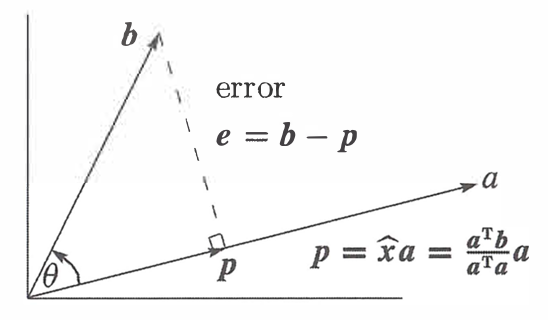 \

Therefore, the projection matrix is

$$
\mathbf{P} = \frac{\mathbf{a}\mathbf{a}^\top}{\mathbf{a}^\top\mathbf{a}}.
$$

This gives a square matrix with rank 1, as the column space is only spanned by $\mathbf{a}$.

There are two interesting properties of $\mathbf{P}$:

- **Symmetric:** $\mathbf{P}=\mathbf{P^\top}$ as $(\mathbf{a}\mathbf{a^\top})^\top = \mathbf{a}\mathbf{a^\top}$.
- **Idempotent:** $\mathbf{P}^2=\mathbf{P}$ as $$\mathbf{P}^2=\frac{\mathbf{a}(\mathbf{a^\top}\mathbf{a})\mathbf{a^\top}}{(\mathbf{a^\top}\mathbf{a})^2} = \mathbf{P}.$$

#### Project Onto a Subspace

Suppose $\mathbf{A}$ has $n$ linearly independent vectors $\mathbf{a_1}, \mathbf{a_2}, \dots, \mathbf{a_n} \in \mathbb{R}^m$. Now, we are interested in finding $\mathbf{p}=\hat{x}_1\mathbf{a_1} + \hat{x}_2\mathbf{a_2} + \cdots + \hat{x}_n\mathbf{a_n}$ closest to a given vector $\mathbf{b}$ that we want to project.

When there is only one vector $\mathbf{a}_1$ (that is, $n=1$), the case is exactly what we have discussed in the previous section. For $n>1$, the best $\mathbf{\hat{x}} = (x_1, x_2, \dots, x_n)$ is to be found now.

The process goes in a similar way:

$$
\begin{bmatrix}- & \mathbf{a_1}^\top & - \\- & \mathbf{a_2}^\top & - \\\vdots \\- & \mathbf{a_n}^\top & - \end{bmatrix} (\mathbf{b} - \mathbf{A}\hat{\mathbf{x}}) = \begin{bmatrix}\mathbf{a_1}^\top(\mathbf{b} - \mathbf{A}\hat{\mathbf{x}}) = 0 \\ \mathbf{a_2}^\top(\mathbf{b} - \mathbf{A}\hat{\mathbf{x}}) = 0 \\ \vdots \\ \mathbf{a_n}^\top(\mathbf{b} - \mathbf{A}\hat{\mathbf{x}}) = 0 \end{bmatrix}.
$$

This is $\mathbf{A}^\top (\mathbf{b} - A\hat{\mathbf{x}}) = \mathbf{0}$. Then,

$$
\begin{aligned}
\mathbf{A}^\top\mathbf{A}\hat{\mathbf{x}} &= \mathbf{A}^\top\mathbf{b} \\
                         \hat{\mathbf{x}} &= (\mathbf{A}^\top\mathbf{A})^{-1}\mathbf{A}^\top\mathbf{b} \\
                               \mathbf{P} &= \mathbf{A}(\mathbf{A}^\top\mathbf{A})^{-1}\mathbf{A}^\top.
\end{aligned}
$$

This matrix is particularly useful in linear regression.

In [20]:
P = A @ np.linalg.inv(A.T @ A) @ A.T
P

array([[ 1.00000000e+00, -4.70734562e-14,  2.22044605e-14],
       [-4.97379915e-14,  1.00000000e+00,  3.19744231e-14],
       [ 1.15463195e-14,  6.66133815e-15,  1.00000000e+00]])

In [21]:
np.allclose(P.T, P), np.allclose(P @ P, P)  # P is symmetric, idempotent

(True, True)

### Orthonormal Bases

The vectors $\mathbf{q}_1, \mathbf{q}_2, \dots, \mathbf{q}_n$ are orthogonal when their dot products $\mathbf{q}_i \cdot \mathbf{q}_j$ are zero. More exactly $\mathbf{q}_i^\top \mathbf{q}_j = 0$ whenever $i \ne j$. With one more step – just divide each vector by its length – the vectors become orthogonal unit vectors. Their lengths are all 1 (normal). Then the basis is called **orthonormal**.

A matrix with orthonormal columns is assigned the special letter $\mathbf{Q}$. The identity matrix $\mathbf{I}$ is a special example of $\mathbf{Q}$. Here is another example, the rotation matrix:

$$
\begin{bmatrix} \cos \theta & - \sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}.
$$

If the columns of $\mathbf{Q}$ are orthogonal, then their dot products are zero, and $\mathbf{Q^\top Q}$ is diagonal. If the columns are orthonormal, then $\mathbf{Q^\top Q}=\mathbf{I}$.

#### The Gram-Schmidt Process

The Gram-Schmidt process is a method for converting a set of linearly independent vectors into an orthogonal (or orthonormal) set that spans the same subspace.

Given linearly independent vectors $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_n\}$, Gram-Schmidt produces orthogonal vectors $\{\mathbf{q}_1, \mathbf{q}_2, \dots, \mathbf{q}_n\}$ by

$$
\begin{aligned}
\mathbf{q}_1 &= \mathbf{v}_1 \\
\mathbf{q}_2 &= \mathbf{v}_2 - \mathrm{proj}_{\mathbf{q}_1} \mathbf{v}_2 \\
\mathbf{q}_3 &= \mathbf{v}_3 - \mathrm{proj}_{\mathbf{q}_1} \mathbf{v}_3 - \mathrm{proj}_{\mathbf{q}_2} \mathbf{v}_3 \\
&\ \vdots \\
\mathbf{q}_k &= \mathbf{v}_k - \sum_{j=1}^{k-1} \mathrm{proj}_{\mathbf{q}_j} \mathbf{v}_k.
\end{aligned}
$$

where the projection is defined as
$$
\mathrm{proj}_{\mathbf{q}} \mathbf{v} = \frac{\mathbf{q}^\top\mathbf{v}}{\mathbf{q}^\top\mathbf{q}} \mathbf{q},
$$

same as what we have discussed in the previous section.

If normalization is applied (i.e., dividing each by its norm), the result is an orthonormal set.

In [22]:
v1_A, v2_A, v3_A = np.hsplit(A, A.shape[1])
v1_A, v2_A, v3_A

(array([[ 2.],
        [ 4.],
        [-2.]]),
 array([[ 4.],
        [ 9.],
        [-3.]]),
 array([[-2.],
        [-3.],
        [ 7.]]))

In [23]:
def proj(q, v):
    return q.T @ v / (q.T @ q) * q

In [24]:
q1_A = v1_A
q2_A = v2_A - proj(q1_A, v2_A)
q3_A = v3_A - proj(q1_A, v3_A) - proj(q2_A, v3_A)

In [25]:
q1_A /= np.linalg.norm(q1_A)
q2_A /= np.linalg.norm(q2_A)
q3_A /= np.linalg.norm(q3_A)

In [26]:
Q = np.hstack([q1_A, q2_A, q3_A])
Q

array([[ 0.40824829, -0.12309149,  0.90453403],
       [ 0.81649658,  0.49236596, -0.30151134],
       [-0.40824829,  0.86164044,  0.30151134]])

In [27]:
np.allclose(Q.T @ Q, np.identity(Q.shape[1]))

True

#### QR Factorization

We are now interested in how $\mathbf{A}$ is related to $\mathbf{Q}$.

Since Gram-Schmidt expresses each column $\mathbf{a}_j$ of $\mathbf{A}$ as a linear combination of the first $j$ orthonormal vectors, we write

$$
\mathbf{a}_j = \sum_{i=1}^{j} r_{ij} \mathbf{q}_i.
$$

$r_{ij} = 0$ whenever $i > j$, because no future orthogonal vector contributes to earlier columns. Hence, $\mathbf{A}=\mathbf{QR} \Longleftrightarrow \mathbf{R}=\mathbf{Q}^{-1}\mathbf{R}=\mathbf{Q^\top R}$ where $\mathbf{R}$ is upper triangular.

In [28]:
R = Q.T @ A
R

array([[ 1.00000000e+00,  1.02062073e+01, -6.12372436e+00],
       [-5.51519787e-16,  1.35400640e+00,  4.80056815e+00],
       [ 2.03529210e-15,  1.70974346e-14,  1.20604538e+00]])

In [29]:
np.allclose(A, Q @ R)

True

In [30]:
np.allclose(R, np.triu(R))  # Is R upper triangular?

True

## Determinants

The determinant of a **square** matrix $\mathbf{A}$, denoted $\det(\mathbf{A})$ or $|\mathbf{A}|$, is a scalar value that summarizes certain properties of the matrix.

### Properties of Determinants

1. $|\mathbf{I}| = 1$.
2. The determinant changes sign when two rows are exchanged.
3. The determinant is a linear function of each row separately:
   $$\begin{vmatrix}a+a' & b+b' \\ c & d\end{vmatrix} = \begin{vmatrix}a & b \\ c & d\end{vmatrix} + \begin{vmatrix}a' & b' \\ c & d\end{vmatrix},$$
   and
   $$\begin{vmatrix}ta & tb \\ c & d\end{vmatrix} = t\begin{vmatrix}a & b \\ c & d\end{vmatrix}.$$
4. If two rows of $\mathbf{A}$ are equal, then $|\mathbf{A}| = 0$. *This rule follows rule 2.*
5. Subtracting a multiple of one row from another row leaves $|\mathbf{A}|$ unchanged. That is, the determinant is not changed by the elimination steps from $\mathbf{A}$ to $\mathbf{U}$. *This rule follows rules 3 and 4.*
   $$\begin{vmatrix}a & b \\ c-\ell a & d - \ell b \end{vmatrix} = \begin{vmatrix}a & b \\ c & d\end{vmatrix} - \ell \begin{vmatrix}a & b \\ a & b\end{vmatrix} = \begin{vmatrix}a & b \\ c & d \end{vmatrix}.$$
6. A matrix with a row of zeros has a determinant equal to 0. *This rule follows rule 5.*
   $$\begin{vmatrix}a & b \\ 0 & 0 \end{vmatrix} = \begin{vmatrix}a & b \\ c & d\end{vmatrix} - \begin{vmatrix}a & b \\ c & d\end{vmatrix} = 0.$$
7. An (upper/lower) triangular matrix has a determinant equal to the product of diagonal entries. \
   *Proof.* Factor an $a_{11}$from the first row by rule 3. Then factor $a_{22}$ from the second row. Eventually factor $a_{nn}$ from the last row. The determinant is $(a_{11})(a_{22})\cdots(a_{nn}) \det \mathbf{I}$. And by rule 1, $\det \mathbf{I} = 1$.
8. A matrix is singular if and only if its determinant is 0. \
   *Proof.* Elimination goes from $\mathbf{A}$ to $\mathbf{U}$. If $\mathbf{A}$ is singular, then $\mathbf{U}$ has a zero row. Rules 4 and 5 give $|\mathbf{A}| = |\mathbf{U}| = 0$. If $\mathbf{A}$ is non-singular, elimination proceeds without introducing a zero row in $\mathbf{U}$. $\mathbf{U}$ has the pivots along its diagonal. Using rule 7, the product of nonzero pivots gives a nonzero determinant.
9. $|\mathbf{AB}|=|\mathbf{A}| |\mathbf{B}|$. *This rule follows rule 3.* \
    When the matrix $\mathbf{B}$ is $\mathbf{A}^{-1}$, this rule says that the determinant of $\mathbf{A}^{-1}$ is $\frac{1}{|\mathbf{A}|}$.
10. $|\mathbf{A^\top}| = |\mathbf{A}|$. \
    The equation $|\mathbf{A^\top}| = |\mathbf{A}|$ becomes $0 = 0$ when $\mathbf{A}$ is singular (we know that $\mathbf{A^\top}$ is also singular). Otherwise, $\mathbf{A}$ has the usual factorization $\mathbf{PA} = \mathbf{LU}$. Transposing both sides gives $\mathbf{A^\top P^\top} = \mathbf{U^\top L^\top}$. \
    Using rule 9, compare $|\mathbf{P}| |\mathbf{A}| = |\mathbf{L}| |\mathbf{U}|$ with $|\mathbf{A^\top}| |\mathbf{P^\top}| = |\mathbf{U^\top}| |\mathbf{L^\top}|$. \
    First, $|\mathbf{L}| = |\mathbf{L^\top}| = 1$ (both have 1's on the diagonal). Second, $|\mathbf{U}| = |\mathbf{U^\top}|$ (those triangular matrices have the same diagonal). Third, $|\mathbf{P}| = |\mathbf{P^\top}|$ (permutations have $\mathbf{P^\top P} = \mathbf{I}$, so $|\mathbf{P^\top}| |\mathbf{P}| = 1$ by rule 9; thus $|\mathbf{P^\top}|$ and $|\mathbf{P}|$ both equal 1 or both equal -1). So $\mathbf{L}$, $\mathbf{U}$, $\mathbf{P}$ have the same determinants as $\mathbf{L^\top}$, $\mathbf{U^\top}$, $\mathbf{P^\top}$, and this leaves $|\mathbf{A}|=|\mathbf{A^\top}|$.

### What does the determinant mean?

1. **Geometric meaning (for real matrices):** the determinant gives the signed volume of the parallelepiped spanned by the column vectors of $A$.
2. **Algebraic meaning:** the determinant tells whether a matrix is invertible (columns are linearly independent).
3. **Linear transformation meaning:** the determinant describes how the linear transformation scales volume in space.

### Leibniz Formula

For a $n\times n$ matrix $\mathbf{A}$,

$$
|\mathbf{A}| = \sum_{\sigma \in S_n} \text{sgn}(\sigma) \prod_{i=1}^{n} a_{i,\sigma(i)},
$$

where:
- $S_n$ is the set of all permutations of ${1, 2, \dots, n}$.
- $\sigma(i)$ gives the column index chosen for row $i$ under permutation $\sigma$.
- $\text{sgn}(\sigma)$ is the sign of the permutation:
    - $+1$ if $\sigma$ is an even permutation (can be written as an even number of swaps),
    - $-1$ if $\sigma$ is an odd permutation.

### Example when $n=3$

For a $3\times3$ matrix

$$
\mathbf{A} = \begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix},
$$

the formula gives

$$
\begin{aligned}
|\mathbf{A}|= &+aei +bfg +cdh \\
              &−ceg −bdi −afh.
\end{aligned}
$$

This expression includes all 6 permutations of 3 elements, with the correct signs.

In [31]:
detA = np.linalg.det(A)
detA

np.float64(1.6329931618554518)

In [32]:
(a_, b_, c_), (d_, e_, f_), (g_, h_, i_) = A
a_ * e_ * i_ + b_ * f_ * g_ + c_ * d_ * h_ - c_ * e_ * g_ - b_ * d_ * i_ - a_ * f_ * h_

np.float64(1.6329931618554534)

### Laplace Expansion

The determinant can be computed using cofactor expansion along any row $i$,

$$
|\mathbf{A}| = \sum_{j=1}^{n} a_{ij} \mathbf{C}_{ij}
$$

*(it can also be done along any column $j$)*

where:
- $\mathbf{C}_{ij}=(-1)^{i+j}\mathbf{M}_{ij}$ is the cofactor of $a_{ij}$.
- $\mathbf{M}_{ij}$ is the minor, i.e., the determinant of the $(n-1) \times (n-1)$ matrix formed by deleting row $i$ and column $j$ from $\mathbf{A}$.

In [33]:
def sub(mat, row, col):
    return np.delete(np.delete(mat, row, axis=0), col, axis=1)

In [34]:
C11 = np.linalg.det(sub(A, 0, 0))
C12 = -np.linalg.det(sub(A, 0, 1))
C13 = np.linalg.det(sub(A, 0, 2))
A[0, 0] * C11 + A[0, 1] * C12 + A[0, 2] * C13  # Expand along first row

np.float64(1.6329931618554565)

### Cramer's Rule

If $|\mathbf{A}|$ is non-zero, $\mathbf{Ax}=\mathbf{b}$ is solved by determinants

$$
\begin{aligned}
x_j &= \frac{|\mathbf{B}_j|}{|\mathbf{A}|},
\end{aligned}
$$

where the $\mathbf{B}_j$ has the $j$th column of $\mathbf{A}$ replaced by the vector $\mathbf{b}$.


#### Key Idea

Replace the first column of $\mathbf{I}$ with $\mathbf{x}$. When you multiply this matrix by $\mathbf{A}$, the first column becomes $\mathbf{Ax}$ which is $\mathbf{b}$. The other columns of $\mathbf{B}_1$ are copied from $\mathbf{A}$,

$$
\begin{bmatrix} \ &\ &\ \\ \ & \mathbf{A} &\ \\ \ &\  &\ \end{bmatrix} \begin{bmatrix} | & 0 & 0 \\ \mathbf{x} & 1 & 0 \\ | & 0 & 1 \end{bmatrix} = \underbrace{\begin{bmatrix} | & | & | \\ \mathbf{b} & \text{col}\ 2 & \text{col}\ 3 \\ | & | & | \end{bmatrix}}_{\mathbf{B}_1}.
$$

Take determinants of the three matrices,

$$
\begin{aligned}
|\mathbf{A}| x_1 &= |\mathbf{B}_1| \\
    x_1 &= \frac{|\mathbf{B}_1|}{|\mathbf{A}|}.
\end{aligned}
$$

A similar process is repeated for $x_2, x_3, \dots, x_n$.

In [35]:
B1 = np.hstack([b, A[:, 1:]])
B2 = np.hstack([A[:, [0]], b, A[:, [2]]])
B3 = np.hstack([A[:, :2], b])

x = np.array([[np.linalg.det(B1) / detA], [np.linalg.det(B2) / detA], [np.linalg.det(B3) / detA]])
x

array([[-4.89897949],
       [ 2.        ],
       [ 2.        ]])

In [36]:
np.allclose(A @ x, b)

True

### Inverse of a Matrix

For an invertible $\mathbf{A}$,

$$
\mathbf{A}^{-1} = \frac{1}{|\mathbf{A}|} \mathbf{C^\top},
$$

where $\mathbf{C}=[\mathbf{C}_{ij}]$, the cofactor matrix.


#### Key Idea

We want to show $\mathbf{AC^\top} = |\mathbf{A}|\mathbf{I}$. We use a 3 by 3 matrix $\mathbf{A}$ here for simplicity:

$$
\underbrace{\begin{bmatrix} - & \text{row}\ 1 & - \\ - & \text{row}\ 2 & - \\ - & \text{row}\ 3 & - \end{bmatrix}}_{\mathbf{A}} \underbrace{\begin{bmatrix} | & | & | \\ \text{col}\ 1 & \text{col}\ 2 & \text{col}\ 3 \\ | & | & | \end{bmatrix}}_{\mathbf{C^\top}} = \begin{bmatrix} |\mathbf{A}| & 0 & 0 \\ 0 & |\mathbf{A}| & 0 \\ 0 & 0 & |\mathbf{A}| \end{bmatrix}
$$

(Row $i$ of $\mathbf{A}$) times (row $i$ of $\mathbf{C}$) yields the $|\mathbf{A}|$ on the diagonal; this is exactly described by the Laplace expansion above.

*How to explain the zeros off the main diagonal?*

Consider row 2 of $\mathbf{A}$ times row 1 of $\mathbf{C}$,

$$
a_{21} \mathbf{C}_{11} + a_{22} \mathbf{C}_{12} + a_{23} \mathbf{C}_{13} = 0.
$$

Actually, this is the Laplace expansion for a new matrix, when the second row of $\mathbf{A}$ is copied into its first row. The new matrix $\mathbf{A}^*$ has two equal rows, so $|\mathbf{A}^*| = 0$. This same logic applies to any mismatch between a row of in $\mathbf{A}$ and a different column in $\mathbf{C^\top}$.

In [37]:
C = np.zeros_like(A)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        C[i, j] = np.linalg.det(sub(A, i, j)) * (-1) ** (i + j)
C

array([[ 54.        ,  -4.4907312 ,   1.22474487],
       [-22.        ,   2.04124145,  -0.40824829],
       [  6.        ,  -0.40824829,   0.40824829]])

In [38]:
C.T / detA

array([[ 33.06811153, -13.47219359,   3.67423461],
       [ -2.75      ,   1.25      ,  -0.25      ],
       [  0.75      ,  -0.25      ,   0.25      ]])

In [39]:
np.allclose(C.T / detA, np.linalg.inv(A))

True

## Eigenvalues

Certain vectors $\mathbf{x}$ are in the same direction after the transformation by a $n\times n$ square matrix $\mathbf{A}$:

$$
\mathbf{Ax}=\lambda\mathbf{x}.
$$

These vectors are called **eigenvectors**. The corresponding $\lambda$ values are called **eigenvalues**, which measure how much the eigenvectors are scaled by the transformation. **Zero vector is not considered an eigenvector.**

$$
\begin{aligned}
                               \mathbf{Ax}&= \lambda\mathbf{x} \\
                                          &= \lambda\mathbf{Ix} \\
(\mathbf{A}-\lambda\mathbf{I}) \mathbf{x} &= \mathbf{0}
\end{aligned}
$$

If the equation has a non-zero solution, $\mathbf{A}-\lambda\mathbf{I}$ is not invertible. Its determinant must be zero,

$$
\det(\mathbf{A}-\lambda\mathbf{I}) = 0.
$$

For each eigenvalue $\lambda$, solve $(\mathbf{A}-\lambda\mathbf{I})\mathbf{x}=\mathbf{0}$ to find an eigenvector $\mathbf{x}$.

### Example

Consider $\mathbf{A}=\begin{bmatrix}1 & 2 \\ 2 & 4\end{bmatrix}$. Its eigenvalues are:

$$
\begin{aligned}
                         \det(\mathbf{A} - \lambda\mathbf{I}) &= 0 \\
\begin{vmatrix} 1-\lambda & 2 \\ 2 & 4 - \lambda\end{vmatrix} &= 0 \\
                                       (1-\lambda)(4-\lambda) &= 4 \\
                                           \lambda(\lambda-5) &= 0 \\
                                                      \lambda &\in \{0, 5\}
\end{aligned}
$$

The $n$ roots are the $n$ eigenvalues of $\mathbf{A}$.

The eigenvector corresponds to $\lambda=0$ is

$$
\begin{aligned}
                  (\mathbf{A}-0\mathbf{I}) \mathbf{x} &= \mathbf{0} \\
\begin{bmatrix}1 & 2 \\ 2 & 4\end{bmatrix} \mathbf{x} &= \mathbf{0} \\
\begin{bmatrix}1 & 2 \\ 0 & 0\end{bmatrix} \mathbf{x} &= \mathbf{0} \\
                                           \mathbf{x} &= t\begin{bmatrix}2 \\ -1\end{bmatrix},\quad t \in \mathbb{R}.
\end{aligned}
$$

Notice that **when a matrix has an eigenvalue equal to 0, its determinant is 0**. The matrix is not invertible.

The eigenvector corresponds to $\lambda=5$ is

$$
\begin{aligned}
(\mathbf{A}-5\mathbf{I}) \mathbf{x} &= \mathbf{0} \\
\begin{bmatrix}-4 & 2 \\ 2 & -1\end{bmatrix} \mathbf{x} &= \mathbf{0} \\
\begin{bmatrix}-4 & 2 \\ 0 & 0\end{bmatrix} \mathbf{x} &= \mathbf{0} \\
                                           \mathbf{x} &= t\begin{bmatrix}1 \\ 2\end{bmatrix},\quad t \in \mathbb{R}.
\end{aligned}
$$

In [40]:
A2 = np.array([[1, 9],
               [2, 4]])

In [41]:
eig_res = np.linalg.eig(A2)  # Eigenvectors are given in unit lengths
eig_res

EigResult(eigenvalues=array([-2.,  7.]), eigenvectors=array([[-0.9486833 , -0.83205029],
       [ 0.31622777, -0.5547002 ]]))

In [42]:
lambda1, lambda2 = eig_res.eigenvalues
X = eig_res.eigenvectors  # x_1, x_2, ... in columns

We have seen above that the eigenvalues are the roots of the **characteristic polynomial**. Thus, a matrix has $n$ eigenvalues, though they may not be distinct and may not be real.

Also, note that **elimination does not preserve the eigenvalues**!

### Determinant and Trace

*Definition.* The **trace** of a square matrix is the sum of its diagonal entries.

Specifically, the product of the $n$ eigenvalues equals the determinant. The sum of the $n$ eigenvalues equals the trace. *([Why?](https://math.stackexchange.com/a/546167))*

Here we derive an interesting conclusion: the eigenvalues of a triangular matrix lie along its diagonal. Check the 7th property of determinants.

### Eigendecomposition

If the square matrix $\mathbf{A}$ has $n$ linearly independent eigenvectors, it can be expressed as

$$
\mathbf{A} = \mathbf{X\Lambda X}^{-1},
$$

where:

- $\mathbf{X}$ is a matrix whose columns are eigenvectors, $\begin{bmatrix}\\ \mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_n \\ && \end{bmatrix}$.
- $\mathbf{\Lambda}$ is a diagonal matrix whose entries are the eigenvalues, $\begin{bmatrix}\lambda_1 & 0 & \cdots & 0 \\0 & \lambda_2 & \cdots & 0 \\\vdots & \vdots & \ddots & \vdots \\0 & 0 & \cdots & \lambda_n\end{bmatrix}$.

*Proof.* We will show $\mathbf{AX} = \mathbf{X\Lambda}$.

Left-hand side:

$$
\mathbf{AX} = \begin{bmatrix}\\ \mathbf{Ax}_1 & \mathbf{Ax}_2 & \cdots & \mathbf{Ax}_n \\ && \end{bmatrix} = \begin{bmatrix}\\ \lambda\mathbf{x}_1 & \lambda\mathbf{x}_2 & \cdots & \lambda\mathbf{x}_n \\ && \end{bmatrix}.
$$

Right-hand side:

$$
\begin{bmatrix}\\ \mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_n \\ && \end{bmatrix}\begin{bmatrix}\lambda_1 & 0 & \cdots & 0 \\0 & \lambda_2 & \cdots & 0 \\\vdots & \vdots & \ddots & \vdots \\0 & 0 & \cdots & \lambda_n\end{bmatrix} = \begin{bmatrix}\\ \lambda\mathbf{x}_1 & \lambda\mathbf{x}_2 & \cdots & \lambda\mathbf{x}_n \\ && \end{bmatrix}.
$$

End of proof.

In [43]:
Lambda = np.diag([lambda1, lambda2])
Lambda

array([[-2.,  0.],
       [ 0.,  7.]])

In [44]:
np.allclose(X @ Lambda @ np.linalg.inv(X), A2)

True

### Invertibility and Diagonalizability

There is no connection between invertibility and diagonalizability:

- Invertibility is concerned with the eigenvalues ($\lambda=0$ or $\lambda \ne 0$). 
- Diagonalizability is concerned with the eigenvectors (too few or enough for $\mathbf{X}$).

Let us discuss more on diagonalizability.

For exceptional matrices, an eigenvalue can be repeated. Then there are two different ways to count its **multiplicity**. Always $\text{GM}<\text{AM}$ for each $\lambda$:

- **Geometric Multiplicity (GM):** the number of independent eigenvectors for $\lambda$. It is the dimension of the nullspace of $\mathbf{A}-\lambda\mathbf{I}$.
- **Algebraic Multiplicity (GM):** the number of repetitions of $\lambda$ among the eigenvalues. It is determined by the roots of $\det (\mathbf{A}-\lambda\mathbf{I})=0$.

Consider these two matrices:

$$
\begin{aligned}
\mathbf{A} &= \begin{bmatrix} 3 & 0 \\ 0 & 3 \end{bmatrix}  &\mathbf{B} &= \begin{bmatrix} 3 & 1 \\ 0 & 3 \end{bmatrix}
\end{aligned}
$$

They both have a repeated eigenvalue $3, 3$ ($\text{AM}=2$). However, $\mathbf{A}$ has two eigenvectors: $\begin{bmatrix} 1 \\ 0\end{bmatrix}$ and $\begin{bmatrix} 0 \\ 1\end{bmatrix}$ ($\text{GM}=2$) but $\mathbf{B}$ has only one: $\begin{bmatrix} 1 \\ 0\end{bmatrix}$ ($\text{GM}=1$).

Therefore, $\mathbf{A}$ is diagonalizable, but $\mathbf{B}$ isn't. The nullspace matters here.

### Powers of a Matrix

Computing high powers of a matrix $\mathbf{A}^k$ directly using repeated multiplication can be inefficient and opaque. But if $\mathbf{A}$ is diagonalizable, the process becomes much simpler and more insightful.

$$
\mathbf{A}^k = \underbrace{(\mathbf{X\Lambda X}^{-1})(\mathbf{X\Lambda X}^{-1})\cdots(\mathbf{X\Lambda X}^{-1})}_{k\ \text{times}} = \mathbf{X\Lambda}^k\mathbf{X}^{-1}.
$$

Using the fact that $\mathbf{X}^{-1}\mathbf{X}=\mathbf{I}$, so all intermediate terms cancel neatly.

For $\mathbf{A}^{-1}$ (if $\mathbf{A}$ is invertible), it works similarly:

$$
\mathbf{A}^{-1} = (\mathbf{X\Lambda X}^{-1})^{-1} = \mathbf{X\Lambda}^{-1}\mathbf{X}^{-1}.
$$

$\mathbf{\Lambda}^k$ and $\mathbf{\Lambda}^{-1}$ are easy to compute. Each diagonal entry (eigenvalue) in $\mathbf{\Lambda}$ is simply raised to the $k$-th power ($\lambda_i^k$) or inverted ($1/\lambda_i$).

In [45]:
Lambda ** 3

array([[ -8.,   0.],
       [  0., 343.]])

In [46]:
np.allclose(X @ Lambda ** 3 @ np.linalg.inv(X), A2 @ A2 @ A2)

True

### Spectral Theorem

When $\mathbf{S}$ is a symmetric matrix, then:

- All eigenvalues of $\mathbf{S}$ are real.
- $\mathbf{S}$ is orthogonally diagonalizable, i.e., there exists an orthogonal matrix $\mathbf{Q}$ (so $\mathbf{Q}^\top\mathbf{Q}=\mathbf{I}$) such that
  $$\mathbf{S}=\mathbf{Q}\mathbf{\Lambda}\mathbf{Q}^\top.$$

*Proof.* Suppose $\mathbf{Sx}_1 = \lambda_1\mathbf{x}_1$ and $\mathbf{Sx}_2 = \lambda_2\mathbf{x}_2$, where $\lambda_1\ne\lambda_2$. Take dot products of the first equation with $\mathbf{x}_2$:

$$
\begin{aligned}
(\lambda_1\mathbf{x}_1)^\top \mathbf{x}_2 &= (\mathbf{Sx}_1)^\top \mathbf{x}_2 \\
                                          &= \mathbf{x}_1^\top \mathbf{S}^\top \mathbf{x}_2 \\
                                          &= \mathbf{x}_1^\top \mathbf{S} \mathbf{x}_2 \\
 \mathbf{x}_1^\top \lambda_1 \mathbf{x}_2 &= \mathbf{x}_1^\top \lambda_2 \mathbf{x}_2 \\
           \mathbf{x}_1^\top \mathbf{x}_2 &= 0 \quad \because \lambda_1\ne\lambda_2.
\end{aligned}
$$

There exist eigenvectors that are orthogonal to each other.

## Definiteness 

The discussion in this section concerns a symmetric matrix $\mathbf{S}$.

Starting from the eigenvalue equation $\mathbf{Sx}=\lambda\mathbf{x}$, multiply by $\mathbf{x}^\top$ to get 

$$
\mathbf{x^\top Sx}=\lambda\mathbf{x^\top x}.
$$

If all eigenvalues are positive, the right-hand side is positive because $\mathbf{x^\top x}=\|\mathbf{x}\|^2$ is always positive. So, the left-hand side is positive for any non-zero $\mathbf{x}$. The matrix $\mathbf{S}$ is then **positive definite**.

### Sylvester’s Criterion

A symmetric matrix is positive definite if and only if **all leading principal minors are positive**. A leading principal minor is the determinant of the top-left $k\times k$ submatrix for $k=1,2,\dots,n$. That is,

$$
\begin{vmatrix} a_{11} \end{vmatrix},\ \begin{vmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{vmatrix},\ \begin{vmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{vmatrix},\ \dots,\ \begin{vmatrix} a_{11} & a_{12} & \dots & a_{1n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{n1} & a_{n2} & \dots & a_{nn} \end{vmatrix} >0.
$$

This proof is hard; we skip it.

### More Checks on Positive Definiteness

$\mathbf{S}$ is positive definite when it has **all positive pivots**.

*Proof.* After Gaussian elimination, the matrix is upper triangular with pivots on its diagonal. For a symmetric matrix, positive definiteness implies that all leading principal minors are positive (by Sylvester’s criterion). Since each pivot corresponds to a ratio involving these leading minors, they must all be positive.

Secondly, if the columns of $\mathbf{A}$ are independent, then $\mathbf{S}=\mathbf{A^\top A}$ is positive definite.

*Proof.* This is easy to prove:

$$
\begin{aligned}
\mathbf{x^\top Sx} &= \mathbf{x^\top A^\top Ax} \\
                   &= (\mathbf{Ax})^\top (\mathbf{Ax}) \\
                   &= \|\mathbf{Ax}\|^2 \quad \ge 0.
\end{aligned}
$$

$\mathbf{x}\ne \mathbf{0}$, so $\mathbf{x^\top Sx} \ge \mathbf{0}$.

### Little Conclusion

When a symmetric matrix $\mathbf{S}$ has one of these five properties, it has them all:

1. $\mathbf{x^\top Sx}$ is positive except at $\mathbf{x}=\mathbf{0}$. 
2. All pivots are positive.
3. All leading principal minors (upper left determinants) are positive.
4. All eigenvalues are positive.
5. $\mathbf{S}=\mathbf{A^\top A}$ for a matrix $\mathbf{A}$ with independent columns.


## Single Value Decomposition (SVD)

Consider a vector $\mathbf{u}$ and $\mathbf{Au}=\mathbf{v}$. We may think of it this way: $\mathbf{u}$ is in the column space of $\mathbf{A}$, and it is transformed to a vector $\mathbf{v}$ in the row space.

In [47]:
A3 = np.array([
    [3, 0],
    [0, 2],
    [0, 0]
])

In [49]:
U, Sigma, VT = np.linalg.svd(A3)
U, Sigma, VT

(array([[ 0.45074388,  0.79382825,  0.40824829],
        [ 0.56919238,  0.0967128 , -0.81649658],
        [ 0.68764089, -0.60040265,  0.40824829]]),
 array([1.02427237e+01, 1.04240615e+00, 1.09013829e-16]),
 array([[ 0.16671124,  0.3565508 ,  0.33342247,  0.85668451],
        [ 0.27833527, -0.78084162,  0.55667054,  0.05416418],
        [ 0.7469363 , -0.16580541, -0.62217626,  0.16580541],
        [-0.58036455, -0.4854549 , -0.43800008,  0.4854549 ]]))

## Left/Right Inverses and Pseudoinverses

## References

- Strang, G. (2016). *Introduction to Linear Algebra* (5th ed.). Wellesley-Cambridge Press.